<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/notebooks/05_pos_tagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QPon Reviews — POS Tagging

| | |
|---|---|
| **Input** | `qpon_preprocessed.csv` |
| **Author** | Zeldano Shan Oeffie (5026231118) |

Part-of-Speech tagging on QPon reviews using Stanza's Indonesian NLP pipeline. Analyzes linguistic patterns across positive and negative sentiment.

In [1]:
!pip install stanza -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.2/337.2 kB 24.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import stanza
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

stanza.download('id')
nlp = stanza.Pipeline('id', processors='tokenize,pos', verbose=False)

INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources


---
## 1. Load Data

In [4]:
df = pd.read_csv('qpon_preprocessed.csv')
df['processed'] = df['processed'].fillna('')
print(f'{len(df):,} reviews')
df[['content', 'processed', 'sentiment']].head()

4,659 reviews


,content,processed,sentiment
0,keren,keren,positive
1,tukar vocer qpon saldo udah kepotong status be...,tukar vocer qpon saldo potong status bayar bay...,negative
2,"promonya kurang masih mahal, murahan jga tiktok",promonya mahal murah jga tiktok,negative
3,very good .. all in one..,very good all in one,positive
4,"UNINSTALL AJA GUYS MAKIN LAMA MAKIN JELEK, MAK...",uninstall guys jelek aneh voucher rb besok che...,negative


---
## 2. POS Tagging
Running Stanza on a sample first (full dataset takes a while), then on the full data.

In [5]:
def get_pos(text):
    if not text or not isinstance(text, str) or not text.strip():
        return []
    try:
        doc = nlp(text)
        return [(w.text, w.upos) for sent in doc.sentences for w in sent.words]
    except:
        return []

# test on 3 samples
for i in range(3):
    text = df['processed'].iloc[i]
    tags = get_pos(text)
    print(f'Review {i+1}: {text}')
    print(f'POS tags: {tags}\n')

Review 1: keren
POS tags: [('keren', 'ADJ')]

Review 2: tukar vocer qpon saldo potong status bayar bayar mohon tindak biar
POS tags: [('tukar', 'NOUN'), ('vocer', 'NOUN'), ('qpon', 'NOUN'), ('saldo', 'NOUN'), ('potong', 'NOUN'), ('status', 'NOUN'), ('bayar', 'VERB'), ('bayar', 'VERB'), ('mohon', 'NOUN'), ('tindak', 'NOUN'), ('biar', 'NOUN')]

Review 3: promonya mahal murah jga tiktok
POS tags: [('promonya', 'NOUN'), ('mahal', 'ADJ'), ('murah', 'ADJ'), ('jga', 'X'), ('tiktok', 'NOUN')]



In [6]:
# run on full dataset — this takes a few minutes
print(f'Tagging {len(df):,} reviews...')
df['pos_tags'] = df['processed'].apply(get_pos)
print('Done')

# check how many have tags
tagged = df['pos_tags'].apply(len).gt(0).sum()
print(f'{tagged:,} reviews with POS tags ({tagged/len(df):.1%})')

Tagging 4,659 reviews...
Done
4,614 reviews with POS tags (99.0%)


---
## 3. POS Distribution

/tmp/ipykernel_466/948913982.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pos_df.head(15), x='POS', y='Count', ax=ax, palette='viridis')


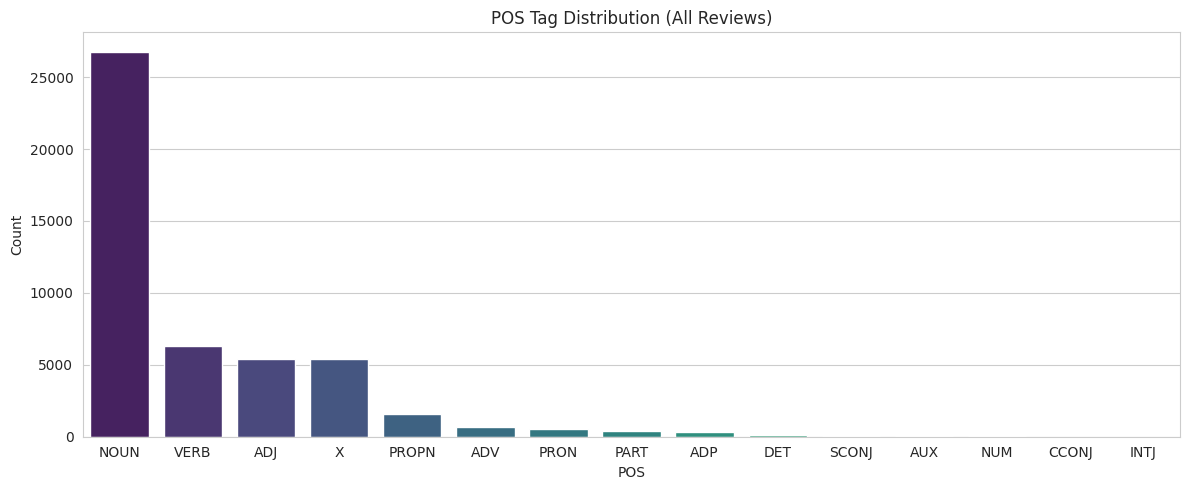

,POS,Count
0,NOUN,26776
1,VERB,6279
2,ADJ,5400
3,X,5377
4,PROPN,1585
5,ADV,698
6,PRON,524
7,PART,426
8,ADP,341
9,DET,89


In [7]:
# count all POS tags
all_pos = []
for tags in df['pos_tags']:
    all_pos.extend([pos for _, pos in tags])

pos_counts = Counter(all_pos)
pos_df = pd.DataFrame(pos_counts.most_common(), columns=['POS', 'Count'])

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=pos_df.head(15), x='POS', y='Count', ax=ax, palette='viridis')
ax.set_title('POS Tag Distribution (All Reviews)')
plt.tight_layout()
plt.show()

pos_df.head(15)

---
## 4. POS Patterns by Sentiment

/tmp/ipykernel_466/875721292.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cdf, x='POS', y='Count', ax=ax, palette=color)
/tmp/ipykernel_466/875721292.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cdf, x='POS', y='Count', ax=ax, palette=color)


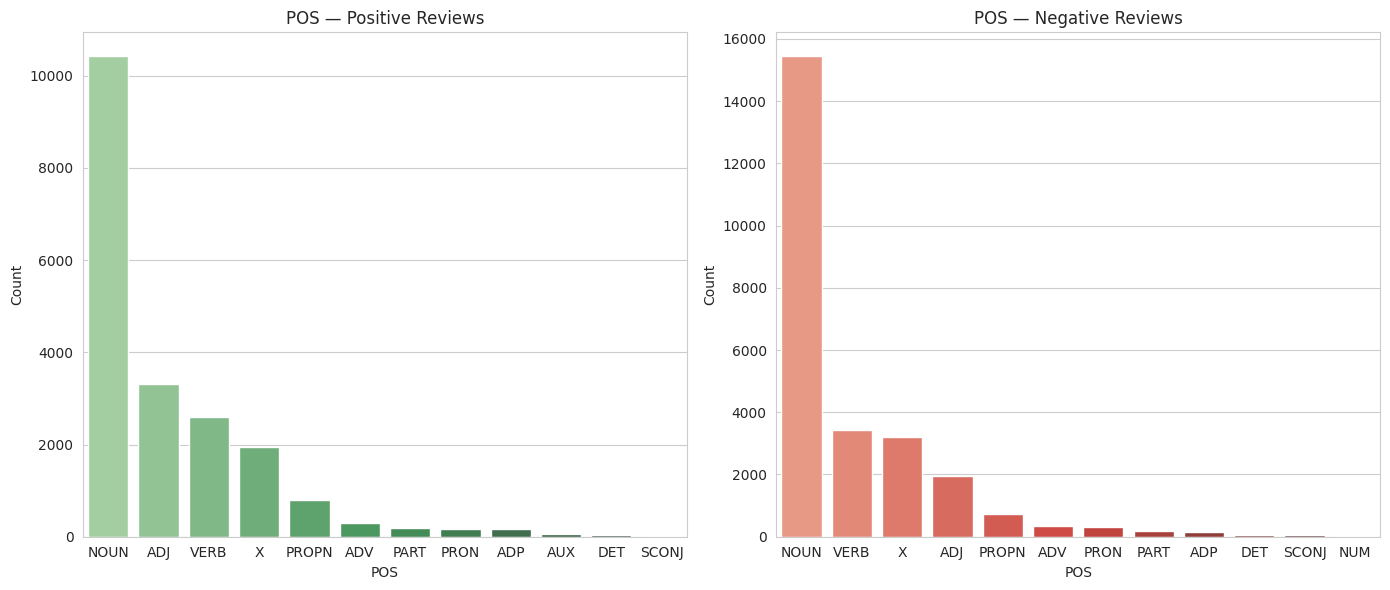

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sent, color in zip(axes, ['positive', 'negative'], ['Greens_d', 'Reds_d']):
    subset = df[df['sentiment'] == sent]
    tags = []
    for t in subset['pos_tags']:
        tags.extend([pos for _, pos in t])
    counts = Counter(tags).most_common(12)
    cdf = pd.DataFrame(counts, columns=['POS', 'Count'])
    sns.barplot(data=cdf, x='POS', y='Count', ax=ax, palette=color)
    ax.set_title(f'POS — {sent.title()} Reviews')

plt.tight_layout()
plt.show()

---
## 5. Top Words by POS Tag

In [9]:
# most common nouns, verbs, adjectives
for target_pos, label in [('NOUN', 'Nouns'), ('VERB', 'Verbs'), ('ADJ', 'Adjectives')]:
    words = [w for tags in df['pos_tags'] for w, pos in tags if pos == target_pos]
    top = Counter(words).most_common(15)
    print(f'\nTop {label}:')
    for w, c in top:
        print(f'  {w:20s} {c:>5,}')


Top Nouns:
  aplikasi             1,599
  qpon                 1,205
  voucher                875
  promo                  659
  diskon                 626
  akun                   500
  refund                 365
  harga                  288
  anak                   281
  apk                    263
  kupon                  263
  login                  256
  makan                  252
  tukar                  245
  uang                   200

Top Verbs:
  beli                   642
  pakai                  403
  masuk                  305
  makan                  293
  bikin                  279
  bayar                  176
  suka                   154
  bantu                  150
  buka                   146
  coba                   130
  tukar                  115
  pilih                  113
  hidup                   87
  hilang                  86
  cari                    79

Top Adjectives:
  hemat                  448
  bagus                  338
  murah                  266
  

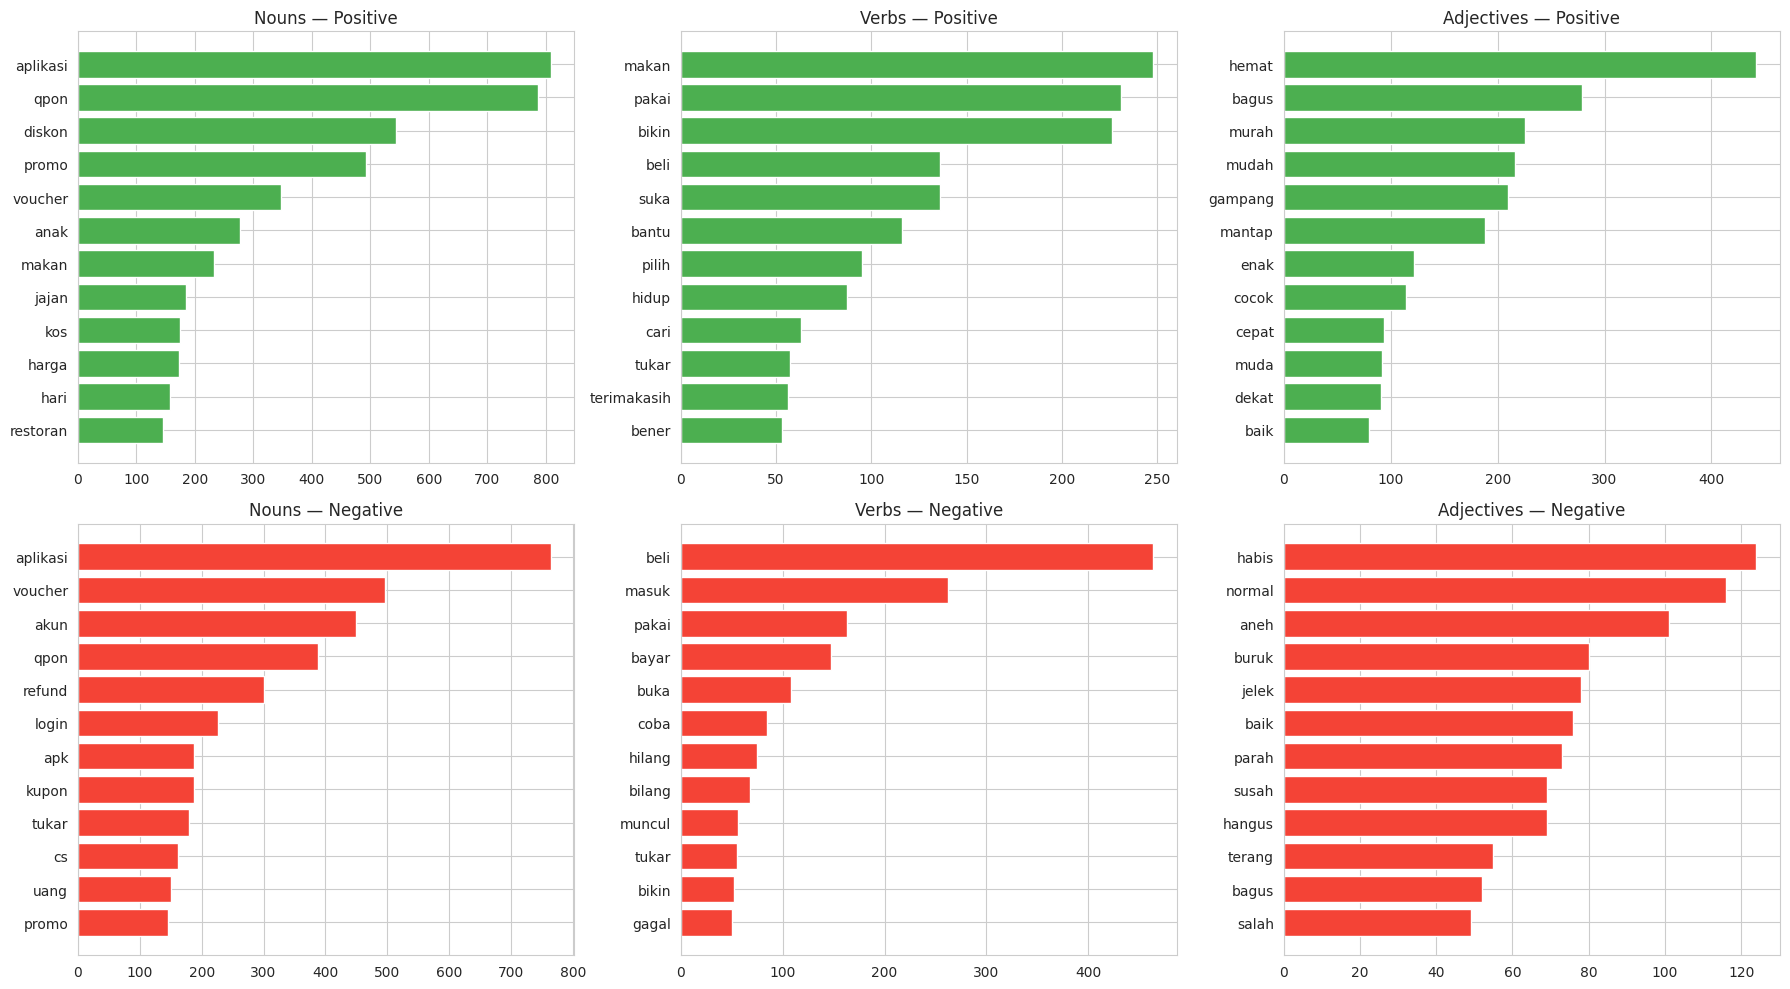

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, sent in enumerate(['positive', 'negative']):
    subset = df[df['sentiment'] == sent]
    for col, (target, label) in enumerate([('NOUN', 'Nouns'), ('VERB', 'Verbs'), ('ADJ', 'Adjectives')]):
        words = [w for tags in subset['pos_tags'] for w, pos in tags if pos == target]
        top = Counter(words).most_common(12)
        cdf = pd.DataFrame(top, columns=['Word', 'Count'])
        color = '#4CAF50' if sent == 'positive' else '#F44336'
        axes[row][col].barh(cdf['Word'][::-1], cdf['Count'][::-1], color=color)
        axes[row][col].set_title(f'{label} — {sent.title()}')

plt.tight_layout()
plt.show()

---
## 6. Save Results

In [11]:
# save POS results
all_words_pos = []
for idx, tags in df['pos_tags'].items():
    sent = df.loc[idx, 'sentiment']
    for word, pos in tags:
        all_words_pos.append({'word': word, 'pos': pos, 'sentiment': sent})

pos_results = pd.DataFrame(all_words_pos)
pos_results.to_csv('pos_tag_results.csv', index=False)
print(f'Saved {len(pos_results):,} word-POS pairs to pos_tag_results.csv')
pos_results.head(10)

Saved 47,663 word-POS pairs to pos_tag_results.csv


,word,pos,sentiment
0,keren,ADJ,positive
1,tukar,NOUN,negative
2,vocer,NOUN,negative
3,qpon,NOUN,negative
4,saldo,NOUN,negative
5,potong,NOUN,negative
6,status,NOUN,negative
7,bayar,VERB,negative
8,bayar,VERB,negative
9,mohon,NOUN,negative


---
## Summary

**POS Tagging** using Stanza's Indonesian pipeline tagged all processed reviews with Universal POS tags.

**Key findings:**
- Nouns and verbs dominate across all reviews
- Positive reviews use more adjectives (bagus, murah, enak)
- Negative reviews have more verbs related to complaints (gagal, error, lambat)
- POS distribution patterns differ between positive and negative sentiment

**Output:** `pos_tag_results.csv` — every word-POS pair with sentiment label.

---
